In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/network_telemetry.csv")

In [3]:
df.head()

,timestamp,device_id,bandwidth,latency,packet_loss,cpu_usage,memory_usage
0,2026-09-01 00:00:00,R-001,35.56,36.97,0.15,32.71,52.60
1,2026-09-01 00:05:00,R-001,27.78,35.10,0.39,29.41,52.49
2,2026-09-01 00:10:00,R-001,35.16,30.07,0.21,36.39,50.59
3,2026-09-01 00:15:00,R-001,39.85,29.22,0.34,40.79,50.82
4,2026-09-01 00:20:00,R-001,32.91,37.60,0.41,40.39,49.46


In [4]:
df.shape

(20160, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     20160 non-null  str    
 1   device_id     20160 non-null  str    
 2   bandwidth     20160 non-null  float64
 3   latency       20160 non-null  float64
 4   packet_loss   20160 non-null  float64
 5   cpu_usage     20160 non-null  float64
 6   memory_usage  20160 non-null  float64
dtypes: float64(5), str(2)
memory usage: 1.1 MB


In [6]:
df.isnull().sum()

timestamp       0
device_id       0
bandwidth       0
latency         0
packet_loss     0
cpu_usage       0
memory_usage    0
dtype: int64

In [7]:
df.describe()

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
count,20160.000000,20160.000000,20160.000000,20160.000000,20160.000000
mean,49.189790,29.873233,0.305353,36.392678,50.435983
std,10.851579,4.592442,0.122937,7.132410,6.204499
min,19.180000,13.920000,0.000000,10.340000,30.020000
25%,40.370000,26.440000,0.220000,31.420000,45.620000
50%,49.580000,29.740000,0.310000,36.310000,49.840000
75%,57.600000,33.310000,0.390000,41.340000,55.342500
max,81.320000,46.070000,0.830000,64.570000,69.150000


In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     20160 non-null  datetime64[us]
 1   device_id     20160 non-null  str           
 2   bandwidth     20160 non-null  float64       
 3   latency       20160 non-null  float64       
 4   packet_loss   20160 non-null  float64       
 5   cpu_usage     20160 non-null  float64       
 6   memory_usage  20160 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.1 MB


In [10]:
print("Start :", df["timestamp"].min())
print("End   :", df["timestamp"].max())

Start : 2026-09-01 00:00:00
End   : 2026-09-07 23:55:00


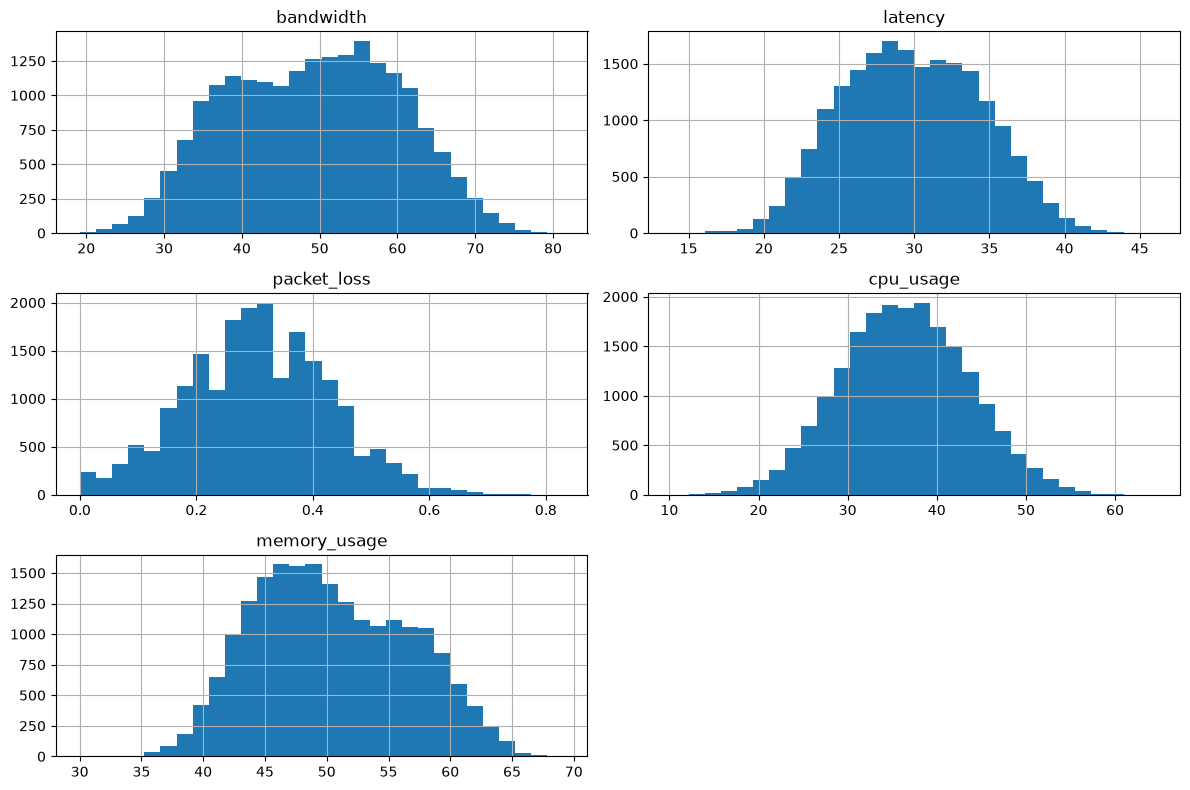

In [11]:
df[[
    "bandwidth",
    "latency",
    "packet_loss",
    "cpu_usage",
    "memory_usage"
]].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [12]:
device_001 = df[df["device_id"] == "R-001"]

device_001.head()

,timestamp,device_id,bandwidth,latency,packet_loss,cpu_usage,memory_usage
0,2026-09-01 00:00:00,R-001,35.56,36.97,0.15,32.71,52.60
1,2026-09-01 00:05:00,R-001,27.78,35.10,0.39,29.41,52.49
2,2026-09-01 00:10:00,R-001,35.16,30.07,0.21,36.39,50.59
3,2026-09-01 00:15:00,R-001,39.85,29.22,0.34,40.79,50.82
4,2026-09-01 00:20:00,R-001,32.91,37.60,0.41,40.39,49.46


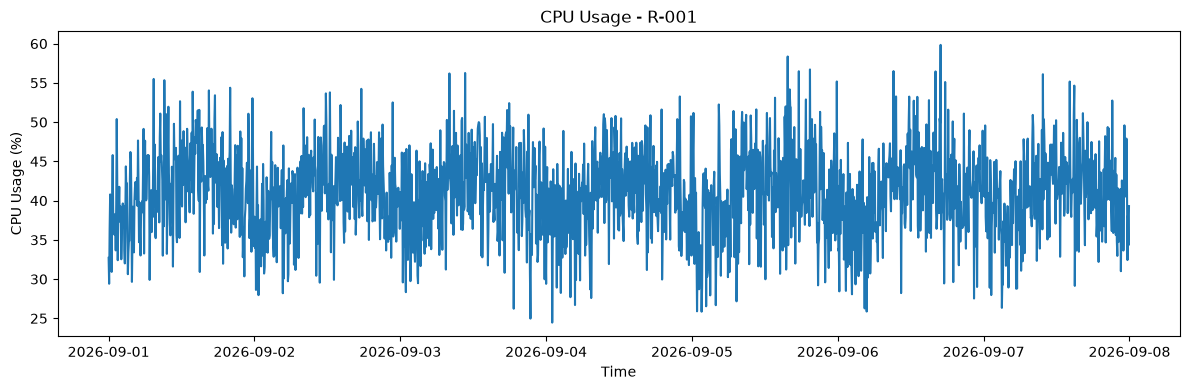

In [13]:
plt.figure(figsize=(12, 4))

plt.plot(
    device_001["timestamp"],
    device_001["cpu_usage"]
)

plt.title("CPU Usage - R-001")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")

plt.tight_layout()
plt.show()

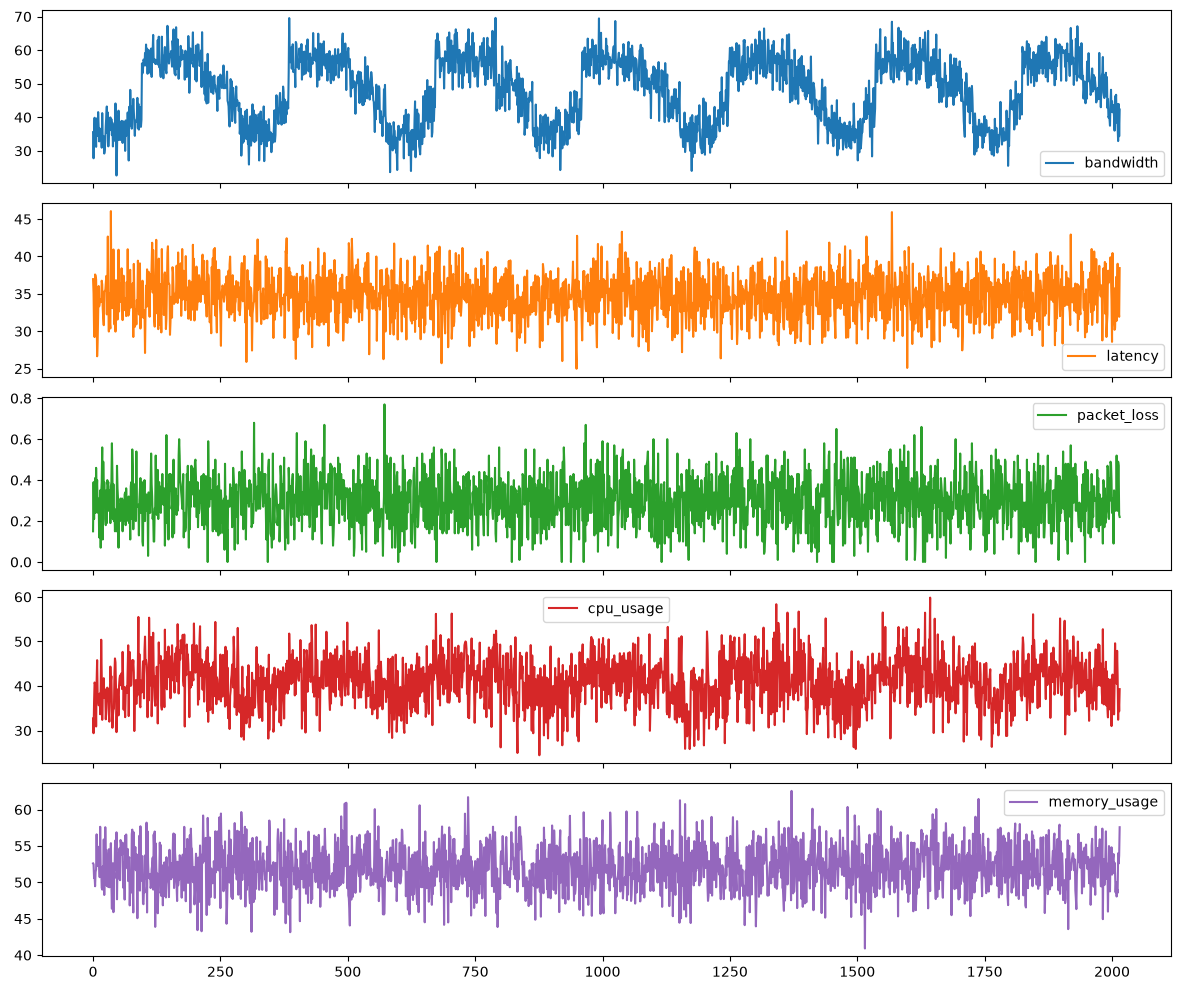

In [14]:
metrics = [
    "bandwidth",
    "latency",
    "packet_loss",
    "cpu_usage",
    "memory_usage"
]

device_001[metrics].plot(
    subplots=True,
    figsize=(12, 10),
    sharex=True
)

plt.tight_layout()
plt.show()

In [15]:
correlation = df[metrics].corr()

correlation

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
bandwidth,1.000000,0.000689,0.083446,0.187865,-0.189037
latency,0.000689,1.000000,-0.000178,0.146352,0.302261
packet_loss,0.083446,-0.000178,1.000000,0.003290,-0.035370
cpu_usage,0.187865,0.146352,0.003290,1.000000,-0.076677
memory_usage,-0.189037,0.302261,-0.035370,-0.076677,1.000000


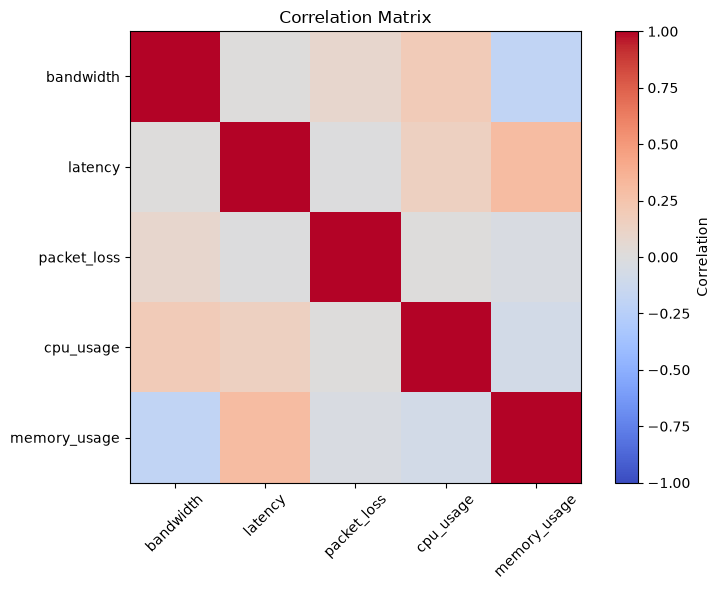

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [17]:
df[metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
bandwidth,20160.0,49.189790,10.851579,19.18,40.37,49.58,57.6000,81.32
latency,20160.0,29.873233,4.592442,13.92,26.44,29.74,33.3100,46.07
packet_loss,20160.0,0.305353,0.122937,0.00,0.22,0.31,0.3900,0.83
cpu_usage,20160.0,36.392678,7.132410,10.34,31.42,36.31,41.3400,64.57
memory_usage,20160.0,50.435983,6.204499,30.02,45.62,49.84,55.3425,69.15


In [18]:
df.groupby("device_id")[metrics].mean().round(2)

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
device_id,,,,,
R-001,48.03,34.67,0.30,40.96,52.02
R-002,43.53,26.58,0.30,31.05,57.44
R-003,52.76,32.48,0.30,30.37,59.43
R-004,57.28,28.31,0.33,32.88,43.69
R-005,46.64,30.31,0.30,36.72,45.81
R-006,52.77,26.90,0.31,34.60,47.27
R-007,49.73,33.08,0.30,33.28,50.26
R-008,52.61,25.84,0.31,39.06,43.40
R-009,41.89,34.57,0.30,44.73,56.20


In [19]:
df.groupby("device_id")[metrics].mean().round(2)

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
device_id,,,,,
R-001,48.03,34.67,0.30,40.96,52.02
R-002,43.53,26.58,0.30,31.05,57.44
R-003,52.76,32.48,0.30,30.37,59.43
R-004,57.28,28.31,0.33,32.88,43.69
R-005,46.64,30.31,0.30,36.72,45.81
R-006,52.77,26.90,0.31,34.60,47.27
R-007,49.73,33.08,0.30,33.28,50.26
R-008,52.61,25.84,0.31,39.06,43.40
R-009,41.89,34.57,0.30,44.73,56.20


In [20]:
df[metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
bandwidth,20160.0,49.189790,10.851579,19.18,40.37,49.58,57.6000,81.32
latency,20160.0,29.873233,4.592442,13.92,26.44,29.74,33.3100,46.07
packet_loss,20160.0,0.305353,0.122937,0.00,0.22,0.31,0.3900,0.83
cpu_usage,20160.0,36.392678,7.132410,10.34,31.42,36.31,41.3400,64.57
memory_usage,20160.0,50.435983,6.204499,30.02,45.62,49.84,55.3425,69.15


In [21]:
df.groupby("device_id")[metrics].mean().round(2)

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
device_id,,,,,
R-001,48.03,34.67,0.30,40.96,52.02
R-002,43.53,26.58,0.30,31.05,57.44
R-003,52.76,32.48,0.30,30.37,59.43
R-004,57.28,28.31,0.33,32.88,43.69
R-005,46.64,30.31,0.30,36.72,45.81
R-006,52.77,26.90,0.31,34.60,47.27
R-007,49.73,33.08,0.30,33.28,50.26
R-008,52.61,25.84,0.31,39.06,43.40
R-009,41.89,34.57,0.30,44.73,56.20


In [22]:
df = pd.read_csv("../data/network_telemetry.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [23]:
print("Shape:", df.shape)
print("Devices:", df["device_id"].nunique())

Shape: (20160, 7)
Devices: 10


In [24]:
metrics = [
    "bandwidth",
    "latency",
    "packet_loss",
    "cpu_usage",
    "memory_usage"
]

correlation = df[metrics].corr()

correlation.round(3)

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
bandwidth,1.000,0.001,0.083,0.188,-0.189
latency,0.001,1.000,-0.000,0.146,0.302
packet_loss,0.083,-0.000,1.000,0.003,-0.035
cpu_usage,0.188,0.146,0.003,1.000,-0.077
memory_usage,-0.189,0.302,-0.035,-0.077,1.000


In [25]:
df.groupby("device_id")[metrics].mean().round(2)

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
device_id,,,,,
R-001,48.03,34.67,0.30,40.96,52.02
R-002,43.53,26.58,0.30,31.05,57.44
R-003,52.76,32.48,0.30,30.37,59.43
R-004,57.28,28.31,0.33,32.88,43.69
R-005,46.64,30.31,0.30,36.72,45.81
R-006,52.77,26.90,0.31,34.60,47.27
R-007,49.73,33.08,0.30,33.28,50.26
R-008,52.61,25.84,0.31,39.06,43.40
R-009,41.89,34.57,0.30,44.73,56.20


In [26]:
df_anomaly = pd.read_csv("../data/network_telemetry_anomaly.csv")
df_anomaly["timestamp"] = pd.to_datetime(df_anomaly["timestamp"])

In [27]:
df_anomaly[df_anomaly["is_anomaly"] == 1].groupby(
    "anomaly_type"
)[metrics].mean().round(2)

,bandwidth,latency,packet_loss,cpu_usage,memory_usage
anomaly_type,,,,,
cpu_overload,47.21,34.89,0.26,93.89,56.35
network_degradation,13.61,119.67,3.97,36.62,49.17
traffic_spike,96.02,29.57,0.38,34.83,42.43


In [28]:
# Pisahkan data normal dan anomaly

normal_data = df_anomaly[df_anomaly["is_anomaly"] == 0].copy()
anomaly_data = df_anomaly[df_anomaly["is_anomaly"] == 1].copy()

print("Normal data :", len(normal_data))
print("Anomaly data:", len(anomaly_data))

Normal data : 20139
Anomaly data: 21


In [29]:
features = [
    "bandwidth",
    "latency",
    "packet_loss",
    "cpu_usage",
    "memory_usage"
]

X_normal = normal_data[features]

print("Fitur yang digunakan:")
print(features)

print("\nShape data normal:")
print(X_normal.shape)

Fitur yang digunakan:
['bandwidth', 'latency', 'packet_loss', 'cpu_usage', 'memory_usage']

Shape data normal:
(20139, 5)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_normal_scaled = scaler.fit_transform(X_normal)

print("Shape:", X_normal_scaled.shape)
print("\nMean:")
print(X_normal_scaled.mean(axis=0).round(4))

print("\nStandard deviation:")
print(X_normal_scaled.std(axis=0).round(4))

Shape: (20139, 5)

Mean:
[-0.  0.  0. -0. -0.]

Standard deviation:
[1. 1. 1. 1. 1.]


In [31]:
import torch

X_normal_tensor = torch.tensor(
    X_normal_scaled,
    dtype=torch.float32
)

print("Shape tensor:", X_normal_tensor.shape)
print("Data type:", X_normal_tensor.dtype)

Shape tensor: torch.Size([20139, 5])
Data type: torch.float32


In [32]:
import torch.nn as nn


class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(5, 3),
            nn.ReLU(),
            nn.Linear(3, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 5)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded

In [33]:
model = Autoencoder()

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=5, bias=True)
  )
)
